# 🔗 Data Lineage Visualizer

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-infra-toolkit/data-lineage-viz/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-infra-toolkit/data-lineage-viz/demo.ipynb)

> **Pain point:** "We don't know what breaks when we change a table."

When a data team changes or drops a table, downstream dashboards and models can break silently.
This notebook parses raw SQL into a **table-to-table dependency graph** and runs **impact analysis**:
given any table, what feeds it (upstream) and what breaks if you change it (downstream).

**What this notebook covers:**
1. Parse SQL (`CREATE TABLE AS`, `CREATE VIEW`, `INSERT INTO`) into lineage edges
2. Build a directed dependency graph with `networkx`
3. Run upstream / downstream impact analysis on a table
4. Visualize the lineage with impact highlighting
5. Try your own SQL


## Step 1 — Parse SQL into lineage edges

Each statement that *writes* a table (`CREATE TABLE x AS ...`, `CREATE VIEW v AS ...`,
`INSERT INTO t ...`) has a **target**. Every table after `FROM` / `JOIN` in that statement
is a **source**. One `(source -> target)` edge per dependency. We strip comments, drop schema
prefixes (`analytics.orders` -> `orders`), and ignore self-references.


In [1]:
from __future__ import annotations

import re
from typing import Dict, List, Set, Tuple, Optional

_TARGET_PATTERNS = [
    re.compile(r'CREATE\s+(?:OR\s+REPLACE\s+)?(?:MATERIALIZED\s+)?VIEW\s+[`"\']?([\w.]+)[`"\']?\s+AS\b', re.IGNORECASE),
    re.compile(r'CREATE\s+(?:TEMP(?:ORARY)?\s+)?TABLE\s+(?:IF\s+NOT\s+EXISTS\s+)?[`"\']?([\w.]+)[`"\']?\s+AS\b', re.IGNORECASE),
    re.compile(r'INSERT\s+INTO\s+[`"\']?([\w.]+)[`"\']?', re.IGNORECASE),
]
_SOURCE_PATTERN = re.compile(r'\b(?:FROM|JOIN)\s+[`"\']?([\w.]+)[`"\']?', re.IGNORECASE)
_NOISE = {"select", "where", "on", "using", "as", "lateral", "unnest"}


def _strip_comments(sql: str) -> str:
    sql = re.sub(r'--[^\n]*', '', sql)
    sql = re.sub(r'/\*.*?\*/', '', sql, flags=re.DOTALL)
    return sql


def _norm(name: str) -> str:
    return name.split('.')[-1].lower()


def parse_lineage(sql: str) -> List[Tuple[str, str]]:
    """Return list of (source_table, target_table) dependency edges."""
    sql_clean = _strip_comments(sql)
    edges: List[Tuple[str, str]] = []
    seen: Set[Tuple[str, str]] = set()
    for stmt in sql_clean.split(';'):
        stmt = stmt.strip()
        if not stmt:
            continue
        target = None
        for pat in _TARGET_PATTERNS:
            m = pat.search(stmt)
            if m:
                target = _norm(m.group(1))
                break
        if not target:
            continue
        for sm in _SOURCE_PATTERN.finditer(stmt):
            source = _norm(sm.group(1))
            if source in _NOISE or source == target:
                continue
            edge = (source, target)
            if edge not in seen:
                seen.add(edge)
                edges.append(edge)
    return edges

print("parse_lineage ready")

parse_lineage ready


## Step 2 — Sample warehouse SQL

A typical dbt-style flow: `raw_*` lands, `stg_*` cleans it, `dim_*` / `fct_*` model it,
`mart_*` aggregates for the business.


In [2]:
SAMPLE_SQL = """
CREATE TABLE stg_orders AS SELECT * FROM raw_orders;
CREATE TABLE stg_customers AS SELECT * FROM raw_customers;

CREATE VIEW dim_customers AS
SELECT * FROM stg_customers;

CREATE TABLE fct_orders AS
SELECT o.id, o.amount, c.region
FROM stg_orders o
JOIN dim_customers c ON o.customer_id = c.id;

INSERT INTO mart_revenue
SELECT region, SUM(amount) FROM fct_orders GROUP BY region;
"""

edges = parse_lineage(SAMPLE_SQL)
for s, t in edges:
    print(f"{s:>15}  -->  {t}")

     raw_orders  -->  stg_orders
  raw_customers  -->  stg_customers
  stg_customers  -->  dim_customers
     stg_orders  -->  fct_orders
  dim_customers  -->  fct_orders
     fct_orders  -->  mart_revenue


## Step 3 — Build the dependency graph + impact analysis

`upstream` = ancestors (everything that feeds the table).
`downstream` = descendants (everything that **breaks if you change it**).


In [3]:
import networkx as nx

def build_graph(edges: List[Tuple[str, str]]) -> nx.DiGraph:
    g = nx.DiGraph()
    g.add_edges_from(edges)
    return g


def impact_analysis(g: nx.DiGraph, table: str) -> Dict[str, object]:
    table = _norm(table)
    if table not in g:
        return {"upstream": [], "downstream": [], "exists": False}
    return {
        "upstream": sorted(nx.ancestors(g, table)),
        "downstream": sorted(nx.descendants(g, table)),
        "exists": True,
    }

g = build_graph(edges)
print(f"Tables: {g.number_of_nodes()}   Dependencies: {g.number_of_edges()}\n")

for tbl in ["stg_orders", "fct_orders", "mart_revenue"]:
    res = impact_analysis(g, tbl)
    print(f"Change `{tbl}`:")
    print(f"   upstream   : {res['upstream'] or '(root source)'}")
    print(f"   downstream : {res['downstream'] or '(nothing depends on it)'}\n")

Tables: 7   Dependencies: 6

Change `stg_orders`:
   upstream   : ['raw_orders']
   downstream : ['fct_orders', 'mart_revenue']

Change `fct_orders`:
   upstream   : ['dim_customers', 'raw_customers', 'raw_orders', 'stg_customers', 'stg_orders']
   downstream : ['mart_revenue']

Change `mart_revenue`:
   upstream   : ['dim_customers', 'fct_orders', 'raw_customers', 'raw_orders', 'stg_customers', 'stg_orders']
   downstream : (nothing depends on it)



## Step 4 — Visualize the lineage

We highlight one table (**red**), its downstream impact (**yellow = will break**),
and its upstream sources (**green**). The chart is saved as PNG so it renders on GitHub.


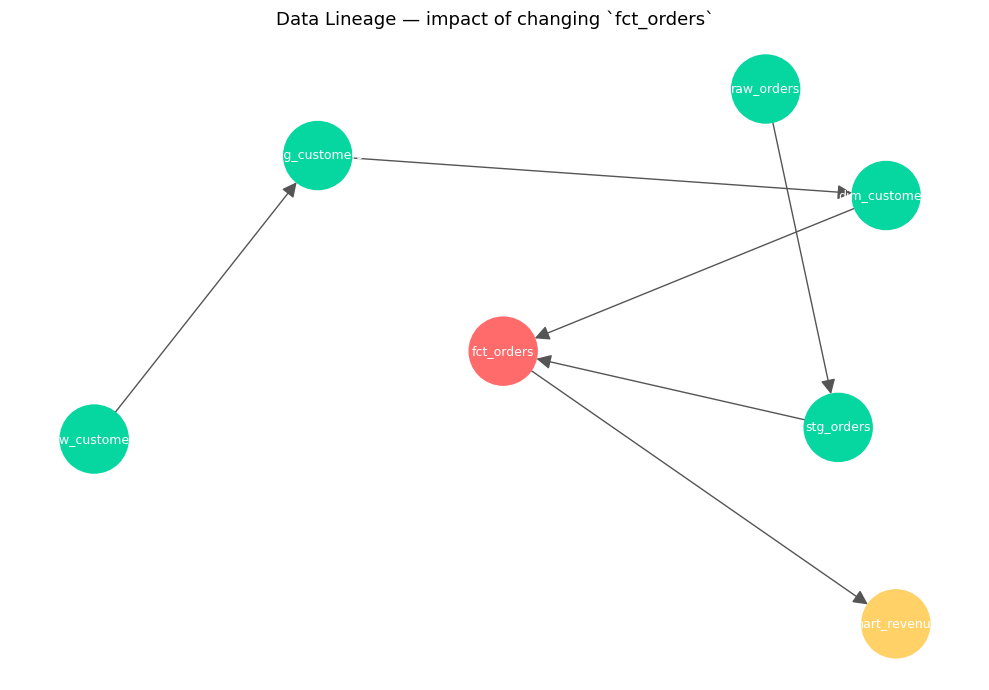

Red = changed table | Yellow = breaks downstream | Green = upstream sources


In [4]:
import matplotlib.pyplot as plt

def draw_graph(g: nx.DiGraph, highlight: Optional[str] = None):
    fig, ax = plt.subplots(figsize=(10, 7))
    pos = nx.spring_layout(g, seed=42, k=1.2)
    hl = _norm(highlight) if highlight else None
    colors = []
    for n in g.nodes():
        if n == hl:
            colors.append("#ff6b6b")
        elif hl and n in nx.descendants(g, hl):
            colors.append("#ffd166")
        elif hl and n in nx.ancestors(g, hl):
            colors.append("#06d6a0")
        else:
            colors.append("#118ab2")
    nx.draw_networkx_nodes(g, pos, node_color=colors, node_size=2400, ax=ax)
    nx.draw_networkx_edges(g, pos, edge_color="#555", arrows=True,
                           arrowsize=22, node_size=2400, ax=ax)
    nx.draw_networkx_labels(g, pos, font_size=9, font_color="white", ax=ax)
    ax.set_title("Data Lineage — impact of changing `fct_orders`", fontsize=13)
    ax.axis("off")
    fig.tight_layout()
    return fig

fig = draw_graph(g, "fct_orders")
fig.savefig("lineage_graph.png", dpi=150, bbox_inches="tight")
plt.show()
print("Red = changed table | Yellow = breaks downstream | Green = upstream sources")

## Summary

| Table | Upstream (depends on) | Downstream (breaks if changed) |
|---|---|---|
| `raw_orders` | — (root) | stg_orders, fct_orders, mart_revenue |
| `stg_orders` | raw_orders | fct_orders, mart_revenue |
| `fct_orders` | raw_*, stg_*, dim_customers | mart_revenue |
| `mart_revenue` | everything above | — (leaf) |

**So what:** before dropping or altering a column in `fct_orders`, you now know `mart_revenue`
depends on it. No more silent dashboard breakage. This is the same column-/table-level impact
analysis that data governance tools (OpenMetadata, DataHub) automate at scale.


## 🧪 Try your own

Paste your own SQL below and re-run. Change `focus` to any of your table names.


In [5]:
# my_sql = """
# CREATE TABLE clean_users AS SELECT * FROM raw_users;
# CREATE VIEW active_users AS SELECT * FROM clean_users WHERE active = 1;
# INSERT INTO report_dau SELECT day, COUNT(*) FROM active_users GROUP BY day;
# """
# my_edges = parse_lineage(my_sql)
# my_g = build_graph(my_edges)
# focus = "clean_users"
# print(impact_analysis(my_g, focus))
# draw_graph(my_g, focus)


---

**Part of [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)** — Day 8 of the 60-day FDE portfolio.

Want the interactive version? Run the Streamlit app:

```bash
pip install -r requirements.txt
streamlit run app.py
```
